<a href="https://colab.research.google.com/github/yaelmartinez6060-boop/-Deep-learning-para-vision-por-computadoras/blob/main/Copia_de_Mini_proy_U1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini Proyecto Unidad 1: Clasificación en CIFAR-10 con ResNet y EfficientNet

* Pipeline completo de clasificación con CNN (ResNet o EfficientNet) sobre CIFAR-10 (Partes 1 a 5)
* Comparativa técnica de dos arquitecturas CNN con curvas de aprendizaje y métricas (Partes 5 y 6)
*Reporte de diseño (arquitectura, hiperparámetros, estrategia de entrenamiento) (Parte 7)

### Recomendación de entorno

Activen GPU en Colab: **Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU**. ResNet-18 y EfficientNet-B0 a resolución 224×224 son considerablemente más pesados que la CNN pequeña de la práctica anterior; en CPU van a funcionar, pero mucho más lento. Las constantes `TAM_TRAIN`, `TAM_VAL` y `N_EPOCAS` están pensadas para ajustarse según el tiempo y el hardware disponible.


## 0. Configuración inicial

In [1]:
!pip install -q torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.4 MB/s eta 0:00:00


In [19]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd

from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassF1Score,
    MulticlassConfusionMatrix,
)

torch.manual_seed(42)

DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DISPOSITIVO)

Dispositivo: cuda


---
## 1. Datos: CIFAR-10 a 224x224

ResNet y EfficientNet, tal como se definen en `torchvision.models`, esperan entradas de 224x224 pixeles (el tamano estandar de ImageNet en el que se disenaron y evaluaron originalmente). Redimensionamos CIFAR-10 (32x32 nativo) a ese tamano.


In [7]:
MEDIA_IMAGENET = (0.485, 0.456, 0.406)
STD_IMAGENET = (0.229, 0.224, 0.225)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEDIA_IMAGENET, STD_IMAGENET),
])

trainset_completo = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

TAM_TRAIN = 5000
TAM_VAL = 1000

resto = len(trainset_completo) - TAM_TRAIN - TAM_VAL
train_subset, val_subset, _ = random_split(
    trainset_completo,
    [TAM_TRAIN, TAM_VAL, resto],
    generator=torch.Generator().manual_seed(42),
)

nombres_clases = trainset_completo.classes
print("Clases:", nombres_clases)
print("Tamano del set de entrenamiento completo:", len(trainset_completo))
print("Tamano del set de prueba:", len(testset))

Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Tamano del set de entrenamiento completo: 50000
Tamano del set de prueba: 10000


### 1.1 Subconjuntos de trabajo



Entrenamiento: 5000 imagenes  |  Validacion: 1000  |  Prueba: 10000


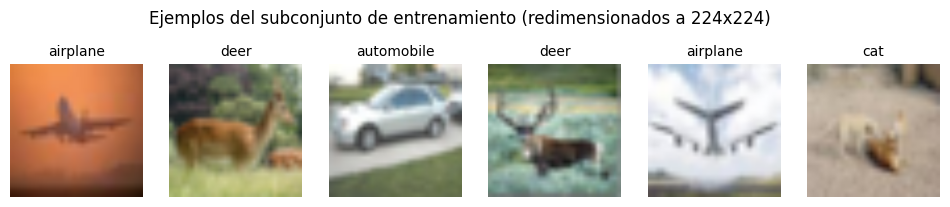

In [8]:
BATCH_SIZE = 32
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

print(f"Entrenamiento: {len(train_subset)} imagenes  |  Validacion: {len(val_subset)}  |  Prueba: {len(testset)}")


def desnormalizar(img_tensor):
    """Invierte la normalizacion para poder visualizar la imagen."""
    media = torch.tensor(MEDIA_IMAGENET).view(3, 1, 1)
    std = torch.tensor(STD_IMAGENET).view(3, 1, 1)
    return (img_tensor * std + media).clamp(0, 1)


imagenes, etiquetas = next(iter(train_loader))
fig, axs = plt.subplots(1, 6, figsize=(12, 2.5))
for i, ax in enumerate(axs):
    ax.imshow(desnormalizar(imagenes[i]).permute(1, 2, 0))
    ax.set_title(nombres_clases[etiquetas[i]], fontsize=10)
    ax.axis("off")
plt.suptitle("Ejemplos del subconjunto de entrenamiento (redimensionados a 224x224)")
plt.show()


---
## 2. Construir ResNet-18 y EfficientNet-B0

Tomamos las arquitecturas de `torchvision.models` con pesos preentrenados en ImageNet (`weights="DEFAULT"`) y adaptamos unicamente la ultima capa para que clasifique entre las 10 clases de CIFAR-10 en vez de las 1000 de ImageNet — el resto de la arquitectura, y sus pesos preentrenados, se conservan exactamente como en 1.3.

Ver : https://docs.pytorch.org/vision/main/models.html


Ejemplo: https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html


In [9]:
# COMPLETAR construir_resnet18(n_clases=10)
#COMPLETAR  construir_efficientnet_b0(n_clases=10)
def construir_resnet18(n_clases=10):
    modelo = models.resnet18(weights="DEFAULT")
    modelo.fc = nn.Linear(modelo.fc.in_features, n_clases)
    return modelo.to(DISPOSITIVO)

def construir_efficientnet_b0(n_clases=10):
    modelo = models.efficientnet_b0(weights="DEFAULT")
    modelo.classifier[1] = nn.Linear(modelo.classifier[1].in_features, n_clases)
    return modelo.to(DISPOSITIVO)

def contar_parametros(modelo):
    return sum(p.numel() for p in modelo.parameters())

torch.manual_seed(42)
modelo_resnet = construir_resnet18()
torch.manual_seed(42)
modelo_efficientnet = construir_efficientnet_b0()

print(f"ResNet-18:       {contar_parametros(modelo_resnet):,} parámetros")
print(f"EfficientNet-B0: {contar_parametros(modelo_efficientnet):,} parámetros")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 166MB/s]

ResNet-18:       11,181,642 parámetros
EfficientNet-B0: 4,020,358 parámetros


---
## 3. Metricas con TorchMetrics

Mismo patron que en la Practica 4 original: `update()` por lote, `compute()` al final de la epoca, `reset()` antes de la siguiente. Usamos `average="macro"` (promedio simple entre las 10 clases)

ver: https://meta-pytorch.org/torcheval/main/torcheval.metrics.html

Ejemplo :  
"accuracy": MulticlassAccuracy(num_classes=n_clases, average="macro").to(DISPOSITIVO),



In [10]:
def crear_metricas(n_clases=10):
    return {
         #Completar
        "accuracy": MulticlassAccuracy(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "precision": MulticlassPrecision(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "recall": MulticlassRecall(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "f1": MulticlassF1Score(num_classes=n_clases, average="macro").to(DISPOSITIVO),
    }


def correr_epoca(modelo, loader, perdida_fn, metricas, optimizador=None):
    """
    Corre una epoca completa. Si optimizador no es None, entrena (backward + step);
    si es None, solo evalua (torch.no_grad()).
    """
    modo_entrenamiento = optimizador is not None
    modelo.train() if modo_entrenamiento else modelo.eval()

    for m in metricas.values():
        m.reset()

    perdida_acumulada, n_lotes = 0.0, 0
    contexto = torch.enable_grad() if modo_entrenamiento else torch.no_grad()

    with contexto:
        for imagenes, etiquetas in loader:
            imagenes, etiquetas = imagenes.to(DISPOSITIVO), etiquetas.to(DISPOSITIVO)

            if modo_entrenamiento:
                optimizador.zero_grad()

            salida = modelo(imagenes)
            perdida = perdida_fn(salida, etiquetas)

            if modo_entrenamiento:
                perdida.backward()
                optimizador.step()

            perdida_acumulada += perdida.item()
            n_lotes += 1

            preds = salida.argmax(dim=1)
            for m in metricas.values():
                m.update(preds, etiquetas)

    resultados = {nombre: m.compute().item() for nombre, m in metricas.items()}
    resultados["loss"] = perdida_acumulada / n_lotes
    return resultados


---
## 4. Entrenar ambos modelos en igualdad de condiciones

Para que la comparacion sea tecnicamente valida, ambos modelos usan **los mismos datos, el mismo numero de epocas, el mismo optimizador y el mismo learning rate**. Documentamos estos hiperparametros aqui porque los van a necesitar tal cual para el reporte de diseno (Parte 7).


In [11]:
LR = 1e-4
N_EPOCAS = 5


def entrenar(modelo, nombre):
    perdida_fn = nn.CrossEntropyLoss()
    optimizador = optim.Adam(modelo.parameters(), lr=LR)
    met_train, met_val = crear_metricas(), crear_metricas()
    historial = []

    for epoca in range(1, N_EPOCAS + 1):
        t0 = time.time()
        r_train = correr_epoca(modelo, train_loader, perdida_fn, met_train, optimizador)
        r_val = correr_epoca(modelo, val_loader, perdida_fn, met_val)
        duracion = time.time() - t0

        historial.append({
            "epoca": epoca,
            "loss_train": r_train["loss"], "acc_train": r_train["accuracy"],
            "loss_val": r_val["loss"],     "acc_val": r_val["accuracy"],
            "segundos": duracion,
        })
        print(f"[{nombre}] época {epoca}/{N_EPOCAS} | "
              f"loss train {r_train['loss']:.3f} val {r_val['loss']:.3f} | "
              f"acc train {r_train['accuracy']:.3f} val {r_val['accuracy']:.3f} | "
              f"{duracion:.1f}s")

    return pd.DataFrame(historial)


print("Hardware:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

df_hist_resnet = entrenar(modelo_resnet, "ResNet-18")
df_hist_efficientnet = entrenar(modelo_efficientnet, "EfficientNet-B0")

Hardware: Tesla T4
[ResNet-18] época 1/5 | loss train 0.788 val 0.382 | acc train 0.741 val 0.862 | 22.3s
[ResNet-18] época 2/5 | loss train 0.193 val 0.357 | acc train 0.947 val 0.874 | 19.3s
[ResNet-18] época 3/5 | loss train 0.059 val 0.310 | acc train 0.991 val 0.892 | 19.8s
[ResNet-18] época 4/5 | loss train 0.021 val 0.280 | acc train 0.999 val 0.907 | 18.9s
[ResNet-18] época 5/5 | loss train 0.026 val 0.280 | acc train 0.997 val 0.905 | 19.7s
[EfficientNet-B0] época 1/5 | loss train 1.305 val 0.480 | acc train 0.635 val 0.851 | 28.6s
[EfficientNet-B0] época 2/5 | loss train 0.424 val 0.323 | acc train 0.866 val 0.897 | 28.5s
[EfficientNet-B0] época 3/5 | loss train 0.229 val 0.263 | acc train 0.933 val 0.917 | 28.4s
[EfficientNet-B0] época 4/5 | loss train 0.130 val 0.268 | acc train 0.965 val 0.917 | 29.2s
[EfficientNet-B0] época 5/5 | loss train 0.094 val 0.278 | acc train 0.974 val 0.919 | 28.6s


In [12]:
print("Historial ResNet-18"); display(df_hist_resnet.round(3))
print("Historial EfficientNet-B0"); display(df_hist_efficientnet.round(3))

Historial ResNet-18


,epoca,loss_train,acc_train,loss_val,acc_val,segundos
0,1,0.788,0.741,0.382,0.862,22.289
1,2,0.193,0.947,0.357,0.874,19.258
2,3,0.059,0.991,0.310,0.892,19.837
3,4,0.021,0.999,0.280,0.907,18.870
4,5,0.026,0.997,0.280,0.905,19.667


Historial EfficientNet-B0


,epoca,loss_train,acc_train,loss_val,acc_val,segundos
0,1,1.305,0.635,0.480,0.851,28.561
1,2,0.424,0.866,0.323,0.897,28.485
2,3,0.229,0.933,0.263,0.917,28.381
3,4,0.130,0.965,0.268,0.917,29.249
4,5,0.094,0.974,0.278,0.919,28.552


---
## 5. Curvas de aprendizaje: ResNet-18 vs. EfficientNet-B0

Mismo diagnostico que en 1.4: comparen el gap train/val de cada modelo, y ahora tambien comparenlos *entre si* — ¿cual generaliza mejor con el mismo presupuesto de datos y epocas?


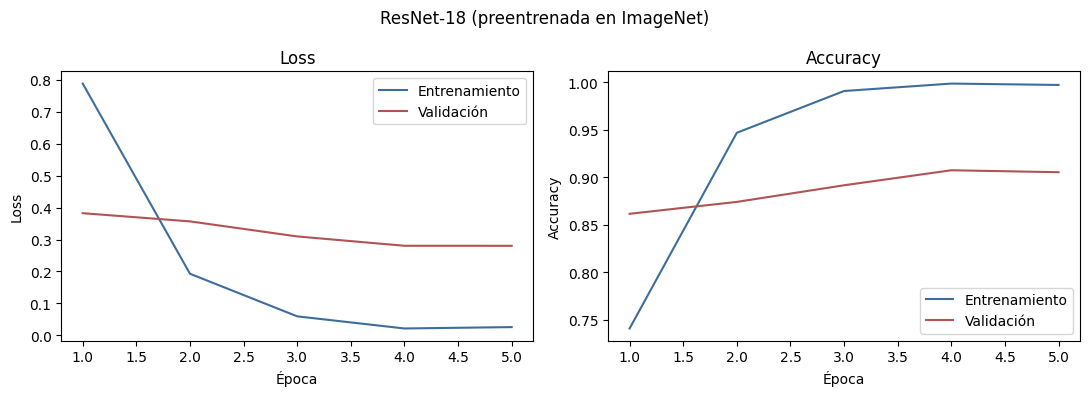

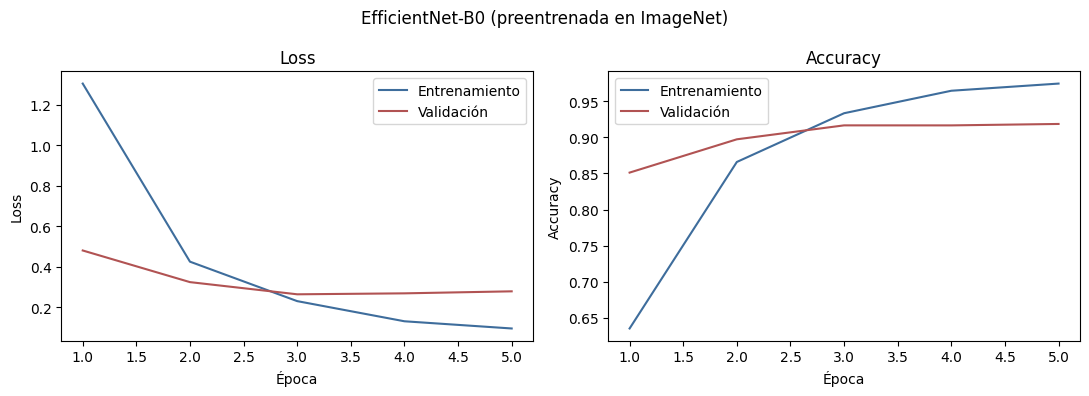

In [13]:
def graficar_curvas(df, titulo):
    fig, axs = plt.subplots(1, 2, figsize=(11, 4))

    axs[0].plot(df["epoca"], df["loss_train"], label="Entrenamiento", color="#3E6D9C")
    axs[0].plot(df["epoca"], df["loss_val"], label="Validación", color="#B15353")
    axs[0].set_xlabel("Época"); axs[0].set_ylabel("Loss"); axs[0].legend()
    axs[0].set_title("Loss")

    axs[1].plot(df["epoca"], df["acc_train"], label="Entrenamiento", color="#3E6D9C")
    axs[1].plot(df["epoca"], df["acc_val"], label="Validación", color="#B15353")
    axs[1].set_xlabel("Época"); axs[1].set_ylabel("Accuracy"); axs[1].legend()
    axs[1].set_title("Accuracy")

    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()

graficar_curvas(df_hist_resnet, "ResNet-18 (preentrenada en ImageNet)")
graficar_curvas(df_hist_efficientnet, "EfficientNet-B0 (preentrenada en ImageNet)")

In [14]:
for nombre, df in [("ResNet-18", df_hist_resnet), ("EfficientNet-B0", df_hist_efficientnet)]:
    gap_acc = df["acc_train"].iloc[-1] - df["acc_val"].iloc[-1]
    gap_loss = df["loss_val"].iloc[-1] - df["loss_train"].iloc[-1]
    print(f"{nombre:16s} | acc train {df['acc_train'].iloc[-1]:.4f}  val {df['acc_val'].iloc[-1]:.4f}"
          f"  | gap acc: {gap_acc:+.4f}  | gap loss: {gap_loss:+.4f}")

ResNet-18        | acc train 0.9973  val 0.9054  | gap acc: +0.0919  | gap loss: +0.2546
EfficientNet-B0  | acc train 0.9745  val 0.9185  | gap acc: +0.0559  | gap loss: +0.1836


---
## 6. Reporte final sobre el set de prueba

Evaluamos ambos modelos sobre las 10,000 imagenes de prueba de CIFAR-10


In [15]:
def evaluar_en_prueba(modelo, nombre_modelo):
    metrica_acc = MulticlassAccuracy(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_prec = MulticlassPrecision(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_rec = MulticlassRecall(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_f1 = MulticlassF1Score(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_matriz = MulticlassConfusionMatrix(num_classes=10).to(DISPOSITIVO)

    modelo.eval()
    with torch.no_grad():
        for imagenes, etiquetas in test_loader:
            imagenes, etiquetas = imagenes.to(DISPOSITIVO), etiquetas.to(DISPOSITIVO)
            preds = modelo(imagenes).argmax(dim=1)
            for m in [metrica_acc, metrica_prec, metrica_rec, metrica_f1, metrica_matriz]:
                m.update(preds, etiquetas)

    resumen = {
        "modelo": nombre_modelo,
        "accuracy": metrica_acc.compute().item(),
        "precision": metrica_prec.compute().item(),
        "recall": metrica_rec.compute().item(),
        "f1": metrica_f1.compute().item(),
    }
    return resumen, metrica_matriz.compute().cpu().numpy()


resumen_resnet, matriz_resnet = evaluar_en_prueba(modelo_resnet, "ResNet-18")
resumen_efficientnet, matriz_efficientnet = evaluar_en_prueba(modelo_efficientnet, "EfficientNet-B0")

df_comparativa = pd.DataFrame([resumen_resnet, resumen_efficientnet]).round(3)
df_comparativa


,modelo,accuracy,precision,recall,f1
0,ResNet-18,0.892,0.891,0.892,0.891
1,EfficientNet-B0,0.918,0.918,0.918,0.917


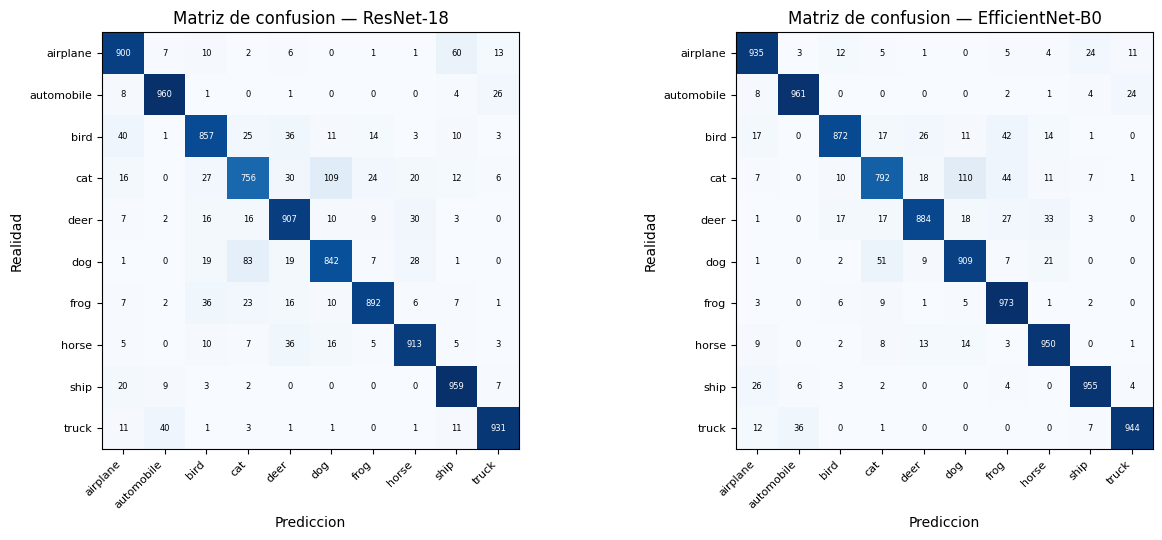

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, matriz, nombre in [(axs[0], matriz_resnet, "ResNet-18"), (axs[1], matriz_efficientnet, "EfficientNet-B0")]:
    im = ax.imshow(matriz, cmap="Blues")
    ax.set_xticks(range(10)); ax.set_xticklabels(nombres_clases, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(10)); ax.set_yticklabels(nombres_clases, fontsize=8)
    ax.set_xlabel("Prediccion"); ax.set_ylabel("Realidad")
    ax.set_title(f"Matriz de confusion — {nombre}")
    for i in range(10):
        for j in range(10):
            color = "white" if matriz[i, j] > matriz.max() / 2 else "black"
            ax.text(j, i, str(int(matriz[i, j])), ha="center", va="center", color=color, fontsize=6)

plt.tight_layout()
plt.show()


In [20]:
def pares_mas_confundidos(matriz, nombres, top=3):
    m = matriz.copy()
    np.fill_diagonal(m, 0)   # quitar los aciertos, quedan solo los errores
    errores = []
    for i in range(10):
        for j in range(10):
            if m[i, j] > 0:
                errores.append((int(m[i, j]), nombres[i], nombres[j]))
    errores.sort(reverse=True)
    return errores[:top]

for nombre, matriz in [("ResNet-18", matriz_resnet), ("EfficientNet-B0", matriz_efficientnet)]:
    print(nombre)
    for veces, real, pred in pares_mas_confundidos(matriz, nombres_clases):
        print(f"  {real} (real) → {pred} (predicho): {veces} veces")
    print()

ResNet-18
  cat (real) → dog (predicho): 109 veces
  dog (real) → cat (predicho): 83 veces
  airplane (real) → ship (predicho): 60 veces

EfficientNet-B0
  cat (real) → dog (predicho): 110 veces
  dog (real) → cat (predicho): 51 veces
  cat (real) → frog (predicho): 44 veces



In [18]:
tabla_final = df_comparativa.copy()
tabla_final["parametros"] = [contar_parametros(modelo_resnet), contar_parametros(modelo_efficientnet)]
tabla_final["seg_por_epoca"] = [df_hist_resnet["segundos"].mean(), df_hist_efficientnet["segundos"].mean()]
tabla_final = tabla_final.round(3)
tabla_final

,modelo,accuracy,precision,recall,f1,parametros,seg_por_epoca
0,ResNet-18,0.892,0.891,0.892,0.891,11181642,19.984
1,EfficientNet-B0,0.918,0.918,0.918,0.917,4020358,28.646


---
## 7. Reporte de diseño (completar en equipo)

Esta seccion es, literalmente, la evidencia **"Reporte de diseño"** del temario de la Unidad 1. Respondan cada punto con base en lo que observaron arriba — pueden editar esta celda de markdown directamente o copiar las respuestas a un documento aparte.

**1. Arquitectura y justificación**
> *(¿Cuál de las dos arquitecturas usarían si solo pudieran quedarse con una para este problema? Justifiquen con los números de la Parte 6, no solo con la teoría de 1.3.)*
- Recomiendo *EfficientNet-B0 ya que usa 2.8 veces menos parámetros (4.02 M contra 11.18 M) y generaliza mejor, su gap de accuracy train/val es 0.056 (ResNet-18: 0.092) y su accuracy casi no cambió entre validación (0.919) y prueba (0.918), mientras que ResNet-18 bajó de 0.905 a 0.892

**2. Hiperparámetros usados**
> Learning rate: `1e-4`  ·  Optimizador: `Adam`  ·  Épocas: `5`  ·  Batch size: `32`  ·  Tamaño del subconjunto de entrenamiento: `5000`  ·  Pesos iniciales: preentrenados (ImageNet) weights="DEFAULT"

**3. Estrategia de entrenamiento**
> *(¿Entrenaron con GPU o CPU? ¿Cuánto tardó cada época de cada modelo? Si tuvieran que reentrenar con más tiempo disponible, ¿qué cambiarían primero: más datos, más épocas, u otro hiperparámetro?)*

- Con GPU en Google Colab (T4)
- El tiempo promedio fue de 19.98 segundos para ResNet-18 y 28.65 segundos para EfficientNet-B0
- Lo primero que cambiaría sería aumentar el tamaño del subconjunto de entrenamiento, esto permitiría a los modelos aprender características más robustas y reducir el overfitting sin añadir costo computacional por iteración

**4. Diagnóstico de las curvas (conexión con 1.4)**
> *(¿Alguno de los dos modelos mostró señales de overfitting según el checklist de la diapositiva 21? ¿Cuál generalizó mejor — menor gap train/val, no necesariamente mayor accuracy?)*

- ResNet-18 presentó un sobreajuste  severo a partir de la época 3, alcanzando casi un 100% de accuracy en entrenamiento, mientras su pérdida en validación dejó de bajar y se estancó en 0.280
- EfficientNet-B0 generalizó significativamente mejor: aunque su accuracy de entrenamiento fue menor (0.974), mantuvo un gap train/val mucho más estrecho (0.056 vs 0.092) y una menor pérdida de validación (0.278).

**5. Capacidad vs. eficiencia (conexión con 1.3)**
> *(Con el número de parámetros de la Parte 2 y el accuracy final de la Parte 6: ¿cuál modelo ofrece mejor relación desempeño/costo computacional en este experimento?)*
- EfficientNet B-0

**6. Errores más frecuentes**
> *(Con las matrices de confusión de la Parte 6: ¿qué par de clases confunde más cada modelo? ¿Tiene sentido esa confusión dado lo que representan esas clases?)*
- cat confundido con dog: Ocurrió 109 veces en ResNet-18 y 110 veces en EfficientNet-B0.   
- dog confundido con cat: Ocurrió 83 veces en ResNet-18 y 51 veces en EfficientNet-B0.   
- airplane / cat confundidos con ship / Rana frog: Ocurrieron entre 44 y 60 veces

Tiene sentido en la práctica, ya que al redimensionar las imágenes de 32 x 32 a 224 x 224 se pierde cierta nitidez, y como los animales comparten posturas, tipos de pelaje y fondos naturales similares, la red confunde fácilmente sus rasgos y los identifica en otra categoría

---
## 8. Cierre y entregables del mini proyecto

### Checklist de entrega

- [ ] Notebook ejecutado de principio a fin, sin errores, con las celdas de ambos modelos corridas.
- [ ] Tabla comparativa final (Parte 6) con accuracy, precision, recall y F1 de ambos modelos.
- [ ] Graficas de curvas de entrenamiento (Parte 5) y matrices de confusion (Parte 6).
- [ ] Reporte de diseno (Parte 7) completado por el equipo.
- [ ] Hiperparametros documentados tal como quedaron configurados al momento de generar los resultados finales.


### Recursos citados

- Katanforoosh, K., & Ng, A. *Stanford CS230* — Section 8, "Advanced Evaluation Metrics". [cs230.stanford.edu/section/8](https://cs230.stanford.edu/section/8)
- TorchMetrics documentation — *Classification: Accuracy*. [torchmetrics.readthedocs.io/en/v0.9.1/classification/accuracy.html](https://torchmetrics.readthedocs.io/en/v0.9.1/classification/accuracy.html)
- Ultralytics. *Consejos y buenas practicas para entrenar modelos*. [docs.ultralytics.com/es/guides/model-training-tips](https://docs.ultralytics.com/es/guides/model-training-tips)
- He, K., Zhang, X., Ren, S., & Sun, J. (2015). Deep residual learning for image recognition. arXiv:1512.03385.
- Tan, M., & Le, Q. (2019). EfficientNet: Rethinking model scaling for convolutional neural networks. ICML 2019.
- Ayyadevara, K., & Reddy, Y. (2024). *Modern Computer Vision with PyTorch*. Packt Publishing.
